In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df=pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

0

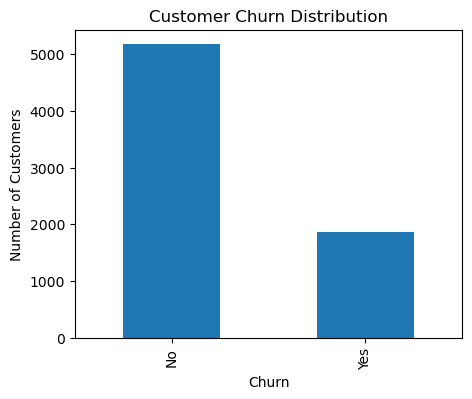

In [9]:
df["Churn"].value_counts().plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [10]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

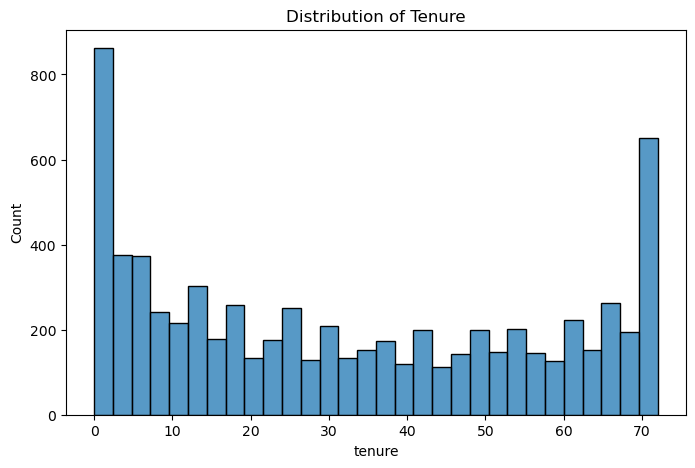

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30)
plt.title("Distribution of Tenure")
plt.show()

In [12]:
df["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

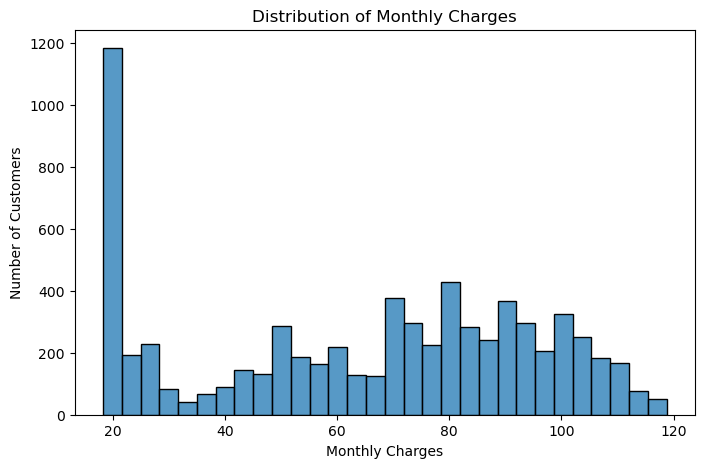

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

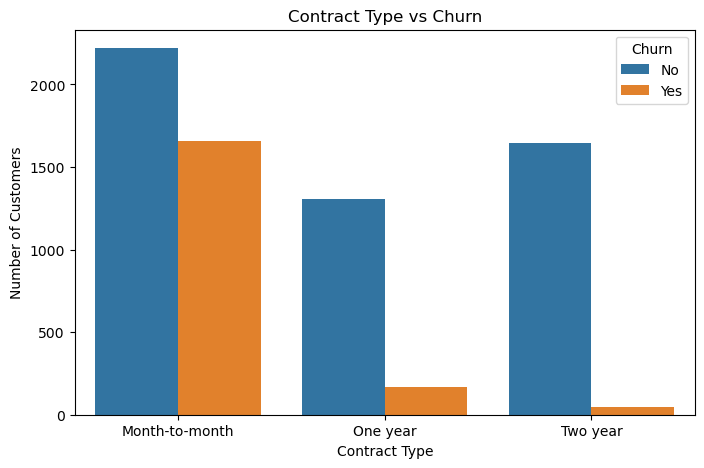

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

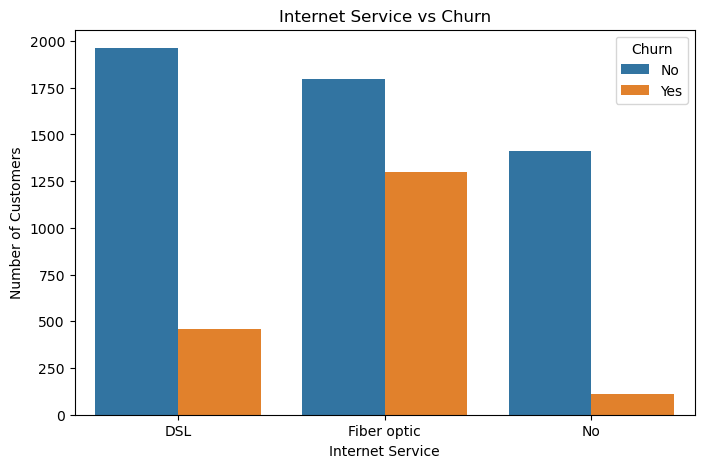

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="InternetService",hue="Churn")
plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

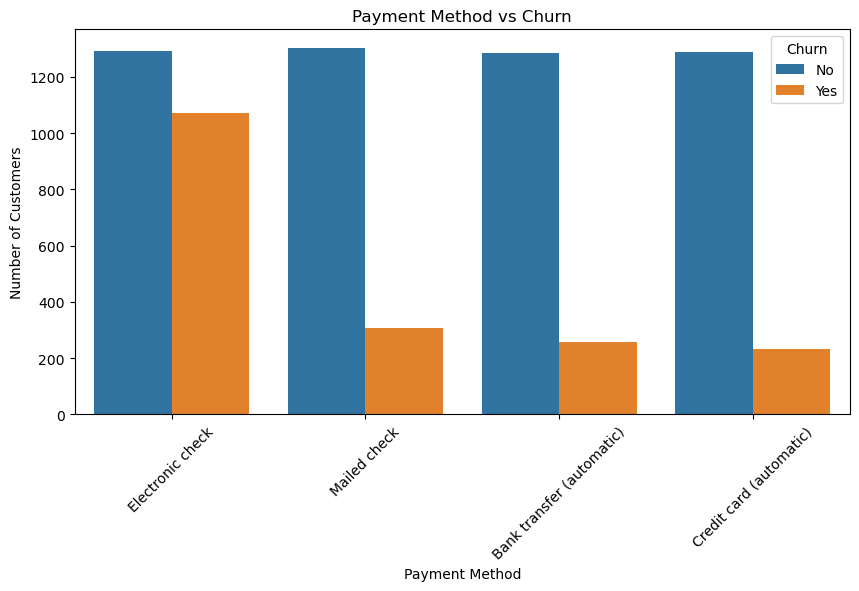

In [16]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,x="PaymentMethod",hue="Churn")

plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

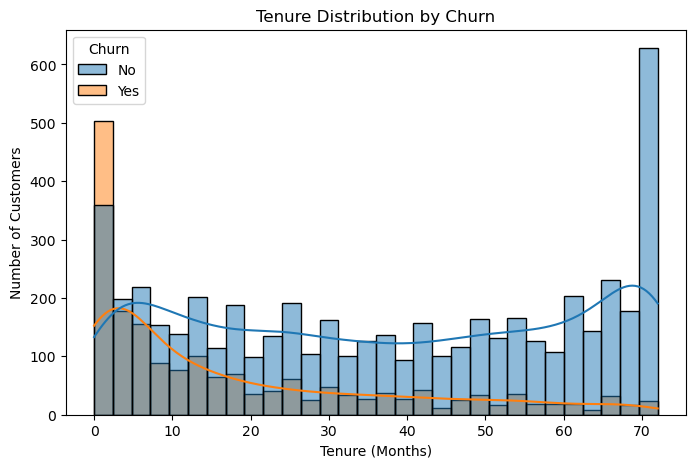

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="tenure",hue="Churn",bins=30,kde=True)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

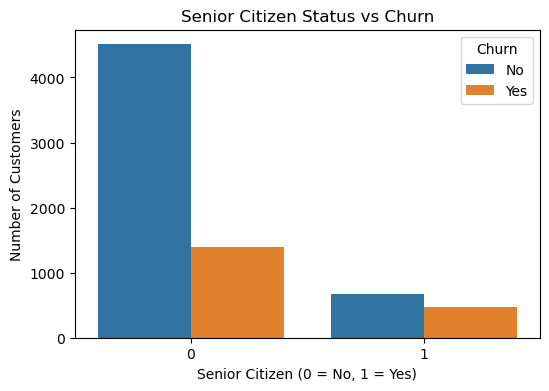

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="SeniorCitizen",hue="Churn"
)

plt.title("Senior Citizen Status vs Churn")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

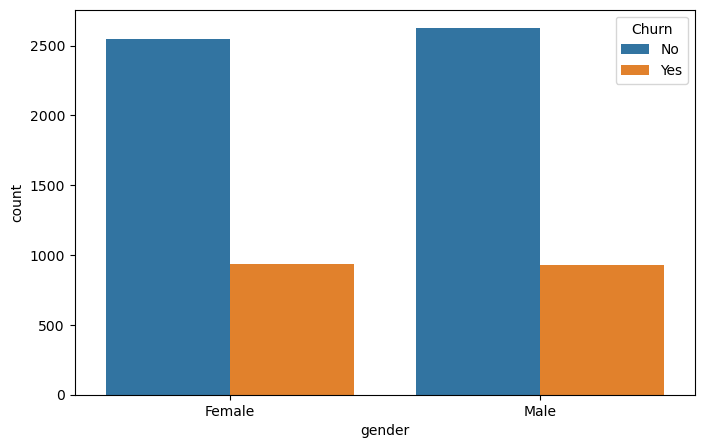

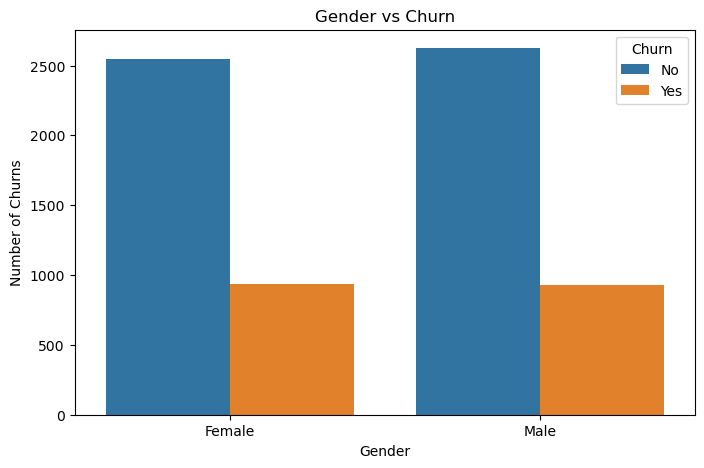

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="gender",hue="Churn")
plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Churns")
plt.show()

#  EDA Summary

## Dataset Overview

* The dataset contains **7,043 customer records** with **21 features**.
* The target variable is **Churn**, making this a **binary classification** problem.
* No duplicate rows were found.
* No missing values were detected using `isnull()`, although the `TotalCharges` column requires further inspection since it is stored as an `object` instead of a numeric type.

---

## Key Findings

### Customer Churn Distribution

* Most customers **do not churn**.
* The dataset is **moderately imbalanced**, with significantly more customers staying than leaving.

### Tenure

* The dataset contains many **new customers** as well as many **long-term customers**.
* Customers with **lower tenure** are more likely to churn, while long-term customers tend to stay.

### Monthly Charges

* Most customers have **lower monthly charges**.
* Higher-priced plans are chosen by fewer customers.

### Contract Type

* Customers with **month-to-month contracts** have the highest churn.
* Customers with **one-year** and **two-year contracts** are much less likely to churn.

### Internet Service

* Customers using **Fiber optic** internet have the highest churn rate.
* Customers without internet service have comparatively lower churn.

### Payment Method

* Customers using **Electronic check** show the highest churn.
* Customers using **automatic payment methods** have lower churn, indicating stronger customer retention.

### Senior Citizen

* Senior citizens have a higher churn rate compared to non-senior citizens.

### Gender

* No significant difference in churn was observed between male and female customers.

---

## Conclusion

The exploratory data analysis suggests that **customer behaviour and service-related factors** have a much stronger relationship with churn than demographic factors like gender.

Features such as **tenure**, **contract type**, **internet service**, **payment method**, and **senior citizen status** appear to be important predictors and will be further processed and used for model building in the next notebook.
